In [3]:
#  Normalization 
# IT24101808

import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

#  Path to dataset
dataset_path = r"C:\Users\USER\Desktop\AI PROJECT\FER_Custom_Dataset"

# Parameters
img_size = (50, 50)
batch_size = 32
train_split = 0.8      # 80% train 20% test
seed = 123             # to keep same train,test split

# Load Train & Test Datasets 
train_data = image_dataset_from_directory(
    dataset_path,
    validation_split=1-train_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale"     # Convert to grayscale (1 channel)
)

test_data = image_dataset_from_directory(
    dataset_path,
    validation_split=1-train_split,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale"     # Convert to grayscale
)

# Normalization 
# Pixel values are in [0,255] --scale to [0,1]
train_data = train_data.map(lambda x, y: (x / 255.0, y))
test_data  = test_data.map(lambda x, y: (x / 255.0, y))

# Check  
for images, labels in train_data.take(1):
    print(" Normalization complete!")
    print("Image batch shape:", images.shape)  # (batch, 50, 50, 1)
    print("Pixel range:", tf.reduce_min(images).numpy(), "to", tf.reduce_max(images).numpy())
    print("Labels shape:", labels.shape)


Found 43819 files belonging to 3 classes.
Using 35056 files for training.
Found 43819 files belonging to 3 classes.
Using 8763 files for validation.
 Normalization complete!
Image batch shape: (32, 50, 50, 1)
Pixel range: 0.0 to 1.0
Labels shape: (32,)


Found 43819 files belonging to 3 classes.
Using 35056 files for training.


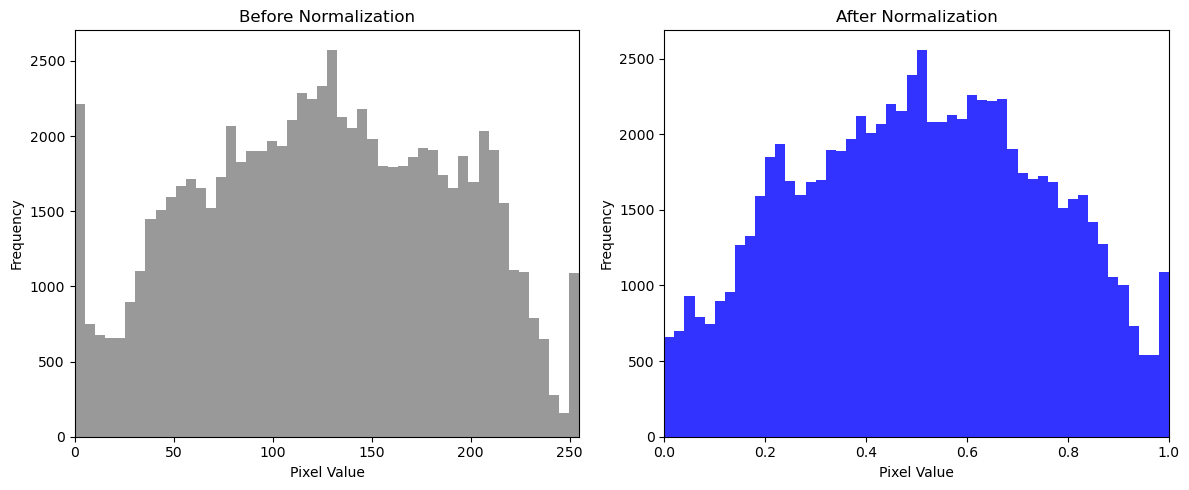

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Take one batch *before* normalization 
raw_data = image_dataset_from_directory(
    dataset_path,
    validation_split=1-train_split,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size,
    color_mode="grayscale"
)

# Take single batch of raw pixels form raw_data
raw_images, _ = next(iter(raw_data))
raw_pixels = raw_images.numpy().flatten()

# Take single batch of normalized pixels from train_data
norm_images, _ = next(iter(train_data))
norm_pixels = norm_images.numpy().flatten()

# Plot Histograms
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(raw_pixels, bins=50, color="gray", alpha=0.8)
plt.title("Before Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.xlim(0, 255)

plt.subplot(1,2,2)
plt.hist(norm_pixels, bins=50, color="blue", alpha=0.8)
plt.title("After Normalization")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.xlim(0, 1)

plt.tight_layout()
plt.show()
